# Demo **Paraphrasing**

Our imposter approach needs models to reword an original text keeping the same meaning.
Ideally, we want to model the way texts originated.
This is dependent on the text's genre, i.e. a student essay originates from a task description and a list of URLs while a new article originates from a list of additional sources or from spectating an event.
We implemented both a naive approach to rewording a text and a more sophisticated one:
- given a prompt and a text, the naive approach uses a language model to paraphrase the text
- given a prompt and a text LLM A is used to extract the text's genre, tone and summary of bullet points, then LLM B is used to reword the text in the same genre and tone based on the summary of bullet points

In [1]:
from pathlib import Path
import os
import textwrap
import sys
# Add the root of the project to Python path
sys.path.append(os.path.abspath(".."))
from config import CONFIG
from genai_detection.paraphrasing.paraphraser import T5ChatGPTParaphraser, T5GooglePAWSParaphraser, BlabladorParaphraser, BulletPointParaphraser, OllamaParaphraser, ParaphrasingEvaluator, TaskParaphraser, TopicParaphraser, TitleParaphraser

/Users/klara/Library/Caches/pypoetry/virtualenvs/generative-ai-detection-PkLo9Jli-py3.11/lib/python3.11/site-packages/pyemd/__init__.py:74: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from .emd import emd, emd_with_flow, emd_samples
[nltk_data] Downloading package wordnet to /Users/klara/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Original text
We use a CNN news article from 23.06.2025 as an example.

In [2]:
path2datasets = Path(os.getcwd()).resolve().parent / "data" / "datasets" / "custom_texts"
path2results = Path(os.getcwd()).resolve().parent / CONFIG.SAVE_PATH / "paraphrasing"
assert path2datasets.exists(), f"Path to datasets {path2datasets} does not exist."
file_name = "cnn_230625"
original_text = open(path2datasets / f"{file_name}.txt").read()

print(textwrap.fill(original_text, width=80))

Vice President JD Vance, in his first public comments since President Donald
Trump authorized US strikes on Iranian nuclear sites, emphasized that the US is
“not at war” with Iran as he laid out the president’s decision-making process.
“We’re not at war with Iran. We’re at war with Iran’s nuclear program,” Vance
said in an interview with NBC’s “Meet the Press with Kristen Welker,” calling
the strikes a “testament to the power of the American military.”Asked what
intelligence led to the decision, Vance described a “narrow window of
opportunity.” “We had a narrow window of opportunity. We might not have been
able to carry out this attack six months down the road. … We have a narrow
window in which we can set that program back a very long time. It would have
been irresponsible, I think, for the president not to take the action that he
did,” he said. Vance added, “Of course we trust our intelligence community, but
we also trust our instincts. … The Iranians stopped negotiating in good fait

## Naive Approach

In [3]:
paraphrasers = {
                # 'T5_ChatGPT': T5ChatGPTParaphraser(), 
                # 'T5_Google_PAWS': T5GooglePAWSParaphraser(), 
                #'Blablador': BlabladorParaphraser(model_id="1 - Llama3 405 the best general model and big context size"), 
                'Ollama': OllamaParaphraser(model_id="default:latest")
                }
if 'Blablador' in paraphrasers.keys():
    print('Available Blablador models:\n', paraphrasers['Blablador']._get_available_models(verbose=False))

In [4]:
n_responses = 1  # number of paraphrases to generate
max_length = 512  # Maximum length of the generated paraphrase
temperature = 0.7  # Controls the randomness of the output. Lower values make the output more deterministic.

prompts = [
        "Paraphrase the following text and output only the paraphrased version:", 
        "First, extract bullet points capturing the main ideas, then create a text based on these bullet points. Only output the final text (i.e. do not output the bullet points or any additional chain of thoughts):",
        "Paraphrase the sentence by first identifying the main subject, verb, and object. Then find synonyms for each and construct a new sentence. Only output the final paraphrased sentence.",
        "Paraphrase the sentence using the same tone as the original with approximately the same number of words:",
        "Paraphrase this sentence. Do not change the meaning, but use different words and structure. Output only the paraphrased sentence:"
        ]

In [5]:
for paraphraser_name, paraphraser in paraphrasers.items():
    print(f"\n{'='*40}")
    print(f"\nUsing paraphraser: {paraphraser_name}")
    for prompt in prompts:
        print(f"\nPrompt: {prompt}")
        paraphrases = paraphraser.paraphrase(original_text, 
                                             n_responses=n_responses, 
                                             max_length=max_length, 
                                             temperature=temperature, 
                                             prompt=prompt)
        for i, paraphrase in enumerate(paraphrases):
            print(f"Paraphrase {i+1}: {textwrap.fill(paraphrase, width=80)}")



Using paraphraser: Ollama

Prompt: Paraphrase the following text and output only the paraphrased version:


InternalServerError: <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
<hr><center>nginx</center>
</body>
</html>

## Bullet Point Approach

Ollama models are by far the best ones for extracting the genre, tone and summary of bullet points and returning them in a structured way.
Hence, we use the Ollama model as the text extractor and any other model as the text generator.

In [ ]:
models = {'text_extractor': {'name':'Ollama-latest', 'model':OllamaParaphraser(model_id="default:latest")},
          'text_generator': {'name':'Ollama-latest', 'model':OllamaParaphraser(model_id="default:latest")}}
            #'text_generator': {'name':'Blablador-Ministral8b', 'model':BlabladorParaphraser(model_id="1 - Ministral 8b - the fast model")}}
bullet_point_paraphraser = BulletPointParaphraser(text_extractor=models["text_extractor"]['model'], text_generator=models["text_generator"]['model'])
# paraphrases = bullet_point_paraphraser.paraphrase(
#     text=original_text, prompt=None, n_responses=n_responses, max_length=max_length)
# for i, paraphrase in enumerate(paraphrases):
#     print(f"Paraphrase {i+1}:\n{paraphrase}\n")
    # save to file
    # with open(path2datasets / f"paraphrase_{file_name}_e={models["text_extractor"]['name']}_g={models["text_generator"]['name']}_{i+1}.txt", "w") as f:
    #     f.write(paraphrase)

## Task Paraphraser
The task paraphraser extracts the task, tone and genre from the text and then generates a paraphrase based on this information.

In [ ]:
task_paraphraser = TaskParaphraser(text_extractor=models["text_extractor"]['model'], text_generator=models["text_generator"]['model'])
# paraphrases = task_paraphraser.paraphrase(
#     text=original_text, prompt=None, n_responses=n_responses, max_length=max_length)
# for i, paraphrase in enumerate(paraphrases):
#     print(f"Paraphrase {i+1}:\n{paraphrase}\n")

## Topic Paraphraser
The topic paraphraser extracts the topic, tone and genre from the text and then generates a paraphrase based on this information.

In [ ]:
topic_paraphraser = TopicParaphraser(text_extractor=models["text_extractor"]['model'], text_generator=models["text_generator"]['model'])
# paraphrases = topic_paraphraser.paraphrase(
#     text=original_text, prompt=None, n_responses=n_responses, max_length=max_length)
# for i, paraphrase in enumerate(paraphrases):
#     print(f"Paraphrase {i+1}:\n{paraphrase}\n")

## Title Paraphraser
The title paraphraser extracts the title, tone and genre from the text and then generates a paraphrase based on this information.

In [ ]:
title_paraphraser = TitleParaphraser(text_extractor=models["text_extractor"]['model'], text_generator=models["text_generator"]['model'])
# paraphrases = title_paraphraser.paraphrase(
#     text=original_text, prompt=None, n_responses=n_responses, max_length=max_length)
# for i, paraphrase in enumerate(paraphrases):
#     print(f"Paraphrase {i+1}:\n{paraphrase}\n")

## Evaluating the Approaches

In [ ]:
paraphrasers.update({'BulletPoint': bullet_point_paraphraser, 'Task': task_paraphraser, 'Topic': topic_paraphraser, 'Title': title_paraphraser})
paraphrase_evaluator = ParaphrasingEvaluator(paraphrasers=paraphrasers, prompts=prompts, original_text=original_text, n_responses=n_responses, max_length=max_length, temperature=temperature)
df = paraphrase_evaluator.evaluate()
df

Evaluating Paraphrasers:   3%|▎         | 1/35 [00:15<08:56, 15.77s/it]

[ERROR] Scoring failed for 'T5_ChatGPT' with prompt 'Paraphrase the following text and output only the paraphrased version:': 0-dimensional array given. Array must be at least two-dimensional


Evaluating Paraphrasers:   6%|▌         | 2/35 [00:21<05:33, 10.09s/it]

[ERROR] Scoring failed for 'T5_ChatGPT' with prompt 'First, extract bullet points capturing the main ideas, then create a text based on these bullet points. Only output the final text (i.e. do not output the bullet points or any additional chain of thoughts):': 0-dimensional array given. Array must be at least two-dimensional


Evaluating Paraphrasers:   9%|▊         | 3/35 [00:26<04:08,  7.77s/it]

...

[ERROR] Paraphraser 'BulletPoint' with prompt 'None' failed: <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
<hr><center>nginx</center>
</body>
</html>


Evaluating Paraphrasers:  60%|██████    | 21/35 [22:09<17:43, 75.94s/it] 

[ERROR] Paraphraser 'Task' with prompt 'None' failed: <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
<hr><center>nginx</center>
</body>
</html>


Evaluating Paraphrasers:  71%|███████▏  | 25/35 [24:59<09:59, 60.00s/it]


KeyboardInterrupt: 

In [ ]:
df

,model,prompt,parameters,original_text,paraphrased_text,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,bertscore_hash,sem_sim_avg,syn_sim_avg,gohsen_delta
0,T5_ChatGPT,Paraphrase the following text and output only ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","Vice President JD Vance, in his first public c...","The vice president, in his first public commen...",0.003145,0.102191,0.232877,0.165517,0.184932,0.184932,0.890928,0.733290,0.804459,0.804459,0.666159,distilbert-base-uncased_L5_no-idf_version=0.3....,0.779859,0.140318,0.639541
1,T5_ChatGPT,"First, extract bullet points capturing the mai...","{'n_responses': 1, 'max_tokens': 512, 'tempera...","Vice President JD Vance, in his first public c...",Vice President JD Vance made his first public ...,0.003933,0.102189,0.249158,0.155932,0.195286,0.195286,0.876751,0.743261,0.804506,0.804506,0.831188,distilbert-base-uncased_L5_no-idf_version=0.3....,0.812043,0.149459,0.662583
2,T5_ChatGPT,Paraphrase the sentence by first identifying t...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","Vice President JD Vance, in his first public c...",After expressing his disbelief in the military...,0.000411,0.066880,0.169014,0.078014,0.098592,0.098592,0.852462,0.723547,0.782732,0.782732,0.700630,distilbert-base-uncased_L5_no-idf_version=0.3....,0.768421,0.089339,0.679082
3,T5_ChatGPT,Paraphrase the sentence using the same tone as...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","Vice President JD Vance, in his first public c...",During an interview on “Meet the Press” with K...,0.001392,0.079591,0.226804,0.131488,0.137457,0.137457,0.870987,0.732120,0.795539,0.795539,0.768303,distilbert-base-uncased_L5_no-idf_version=0.3....,0.792497,0.121884,0.670613
4,T5_ChatGPT,Paraphrase this sentence. Do not change the me...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","Vice President JD Vance, in his first public c...",During an interview on “Meet the Press” with K...,0.000252,0.069324,0.178571,0.122302,0.107143,0.107143,0.872695,0.712978,0.784793,0.784793,0.692085,distilbert-base-uncased_L5_no-idf_version=0.3....,0.769469,0.095322,0.674147
5,T5_Google_PAWS,Paraphrase the following text and output only ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","Vice President JD Vance, in his first public c...",In his first public comments since President D...,0.055157,0.244887,0.429907,0.332288,0.398754,0.398754,0.946825,0.808962,0.872481,0.872481,0.786046,distilbert-base-uncased_L5_no-idf_version=0.3....,0.857359,0.294606,0.562753
6,T5_Google_PAWS,"First, extract bullet points capturing the mai...","{'n_responses': 1, 'max_tokens': 512, 'tempera...","Vice President JD Vance, in his first public c...",Vance emphasized that the US was not at war wi...,0.018673,0.174238,0.352941,0.236842,0.235294,0.235294,0.917729,0.767775,0.836081,0.836081,0.813369,distilbert-base-uncased_L5_no-idf_version=0.3....,0.834207,0.202303,0.631904
7,T5_Google_PAWS,Paraphrase the sentence by first identifying t...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","Vice President JD Vance, in his first public c...",In his first public comments since President D...,0.034953,0.217625,0.383387,0.295820,0.332268,0.332268,0.941457,0.785237,0.856280,0.856280,0.768541,distilbert-base-uncased_L5_no-idf_version=0.3....,0.841559,0.250203,0.591356
8,T5_Google_PAWS,Paraphrase the sentence using the same tone as...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","Vice President JD Vance, in his first public c...",In his first public remarks since President Do...,0.070920,0.254254,0.460123,0.376543,0.392638,0.392638,0.922773,0.801205,0.857702,0.857702,0.881583,distilbert-base-uncased_L5_no-idf_version=0.3....,0.864193,0.307894,0.556300
9,T5_Google_PAWS,Paraphrase this sentence. Do not change the me...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","Vice President JD Vance, in his first public c...",In his first public comments since Pr

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_metrics_radar_chart_20250701_172944.png


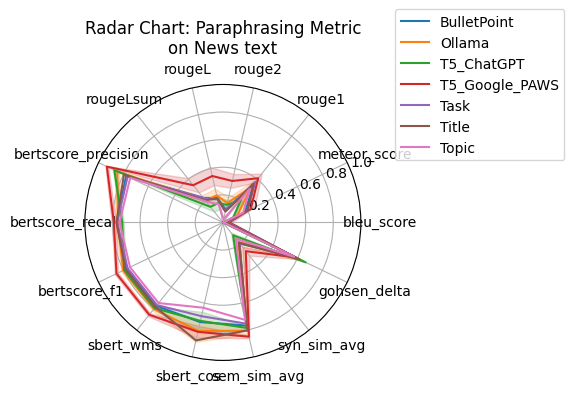

In [ ]:
paraphrase_evaluator.plot_models_metrics(df=df, save_path=path2results, data_category="News")

In [ ]:
paraphrase_evaluator.plot_metric_scatter(df, save_path=path2results, data_category="News")

## Batch Processing

In [ ]:
# Batch paraphrasing
# texts = ["The sky is blue.", "I love programming.", "Artificial intelligence is fascinating."]
# paraphrased_batch = bullet_point_paraphraser.paraphrase_batch(texts)
# for original, paraphrased in zip(texts, paraphrased_batch):
#     print(f"Original: {original} | Paraphrased: {paraphrased}")

In [ ]:
import dirtyjson
d = dirtyjson.loads("""["foo", /* not fu*/ {bar: ['baz', null, 1.0, 2,]}] and then ignore this junk""")
d

['foo', AttributedDict([('bar', ['baz', None, 1.0, 2])])]